In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
from tqdm import tqdm
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Define paths
base_dir = '../data/DAWN_processed'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define classes
classes = ['Fog', 'Rain', 'Snow', 'Sand']

# --- Hyperparameters (Similar to improved BiLSTM, adjust as needed for BiGRU) ---
img_height, img_width = 64, 64
batch_size = 32
epochs = 50
initial_learning_rate = 0.0005
hidden_size = 192 # GRUs might sometimes work well with slightly different sizes than LSTMs
num_layers = 2
dropout_rate = 0.4
weight_decay = 1e-4
scheduler_patience = 5
scheduler_factor = 0.1
early_stopping_patience = 10
# --- End of Hyperparameters ---

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# --- Data transformations with Augmentation ---
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# --- End of Data Transformations ---

# Load datasets
if not os.path.exists(base_dir):
    print(f"Error: Base directory not found at {base_dir}")
    exit()

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# Create data loaders
num_workers = 4 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print(f"Classes: {train_dataset.classes}")
print(f"Class to idx mapping: {train_dataset.class_to_idx}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Classes: ['Fog', 'Rain', 'Sand', 'Snow']
Class to idx mapping: {'Fog': 0, 'Rain': 1, 'Sand': 2, 'Snow': 3}
Training samples: 718
Validation samples: 204
Test samples: 105


In [4]:
# --- Define Bi-directional GRU model ---
class ImageBiGRU(nn.Module):
    """
    Bi-directional GRU model for image classification with Dropout.
    """
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate):
        super(ImageBiGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Use nn.GRU instead of nn.LSTM
        self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, num_classes) # Input is doubled for BiGRU

    def forward(self, x):
        # Initialize hidden state (GRU only has h0, no c0)
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(device)

        # Forward propagate GRU
        # GRU returns outputs and the last hidden state(s)
        out, _ = self.rnn(x, h0) # Pass h0

        # Apply dropout to the output of the last time step
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Instantiate the BiGRU model
model = ImageBiGRU(img_width, hidden_size, num_layers, len(classes), dropout_rate).to(device)
print(model)
# --- End of BiGRU Model Definition ---

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer and Scheduler (AdamW and ReduceLROnPlateau)
optimizer = optim.AdamW(model.parameters(), lr=initial_learning_rate, weight_decay=weight_decay)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=scheduler_factor,
                                           patience=scheduler_patience, verbose=True)


ImageBiGRU(
  (rnn): GRU(64, 192, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=384, out_features=4, bias=True)
)


F:\venvs\main\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [5]:
# Training function (Identical to the previous one, just uses BiGRU model)
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, early_stopping_patience):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    print("\n--- Starting BiGRU Training ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            current_lr = optimizer.param_groups[0]['lr']
            train_bar.set_postfix({'loss': f'{loss.item():.4f}',
                                   'acc': f'{100 * correct / total:.2f}%',
                                   'lr': f'{current_lr:.1e}'})

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        print(f'\nEpoch {epoch + 1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"-> Validation Loss Improved - Saving Best Model")
        else:
            epochs_no_improve += 1
            print(f"-> Validation Loss Did Not Improve for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= early_stopping_patience:
            print(f"\n--- Early Stopping Triggered after {epoch + 1} epochs ---")
            break

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with final validation loss: {best_val_loss:.4f}")
    else:
         print("\nWarning: No best model state was saved.")
    print("--- Finished BiGRU Training ---")
    return model, history


In [6]:
# Evaluation function (Identical)
def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    desc = "Evaluating" if criterion else "Testing"
    with torch.no_grad():
        eval_bar = tqdm(data_loader, desc=desc, leave=False)
        for inputs, labels in eval_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)
            outputs = model(inputs)
            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            eval_bar.set_postfix({'acc': f'{100 * correct / total:.2f}%'})
    avg_loss = running_loss / len(data_loader.dataset) if criterion and len(data_loader.dataset) > 0 else 0
    acc = 100 * correct / total if total > 0 else 0
    return avg_loss, acc


In [7]:
# Plot function (Update titles and filenames)
def plot_training_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
    epochs_range = range(1, len(history['train_acc']) + 1)

    ax1.plot(epochs_range, history['train_acc'], label='Train')
    ax1.plot(epochs_range, history['val_acc'], label='Validation')
    ax1.set_title('Model Accuracy (BiGRU)'); ax1.set_ylabel('Accuracy (%)')
    ax1.set_xlabel('Epoch'); ax1.legend(loc='lower right'); ax1.grid(True)

    ax2.plot(epochs_range, history['train_loss'], label='Train')
    ax2.plot(epochs_range, history['val_loss'], label='Validation')
    ax2.set_title('Model Loss (BiGRU)'); ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch'); ax2.legend(loc='upper right'); ax2.grid(True)

    ax3.plot(epochs_range, history['lr'], label='Learning Rate')
    ax3.set_title('Learning Rate Schedule'); ax3.set_ylabel('Learning Rate')
    ax3.set_xlabel('Epoch'); ax3.set_yscale('log'); ax3.legend(loc='upper right'); ax3.grid(True)

    plt.tight_layout()
    plt.savefig('training_history_bigru.png') # Updated filename
    print("Training history plot saved as 'training_history_bigru.png'")
    plt.show()


In [8]:
# Confusion matrix function (Update titles and filenames)
def plot_confusion_matrix(model, data_loader, classes):
    y_true = []; y_pred = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Generating predictions for CM"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy()); y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (BiGRU)') # Updated title
    plt.savefig('confusion_matrix_bigru.png') # Updated filename
    print("Confusion matrix plot saved as 'confusion_matrix_bigru.png'")
    plt.show()
    print("\nClassification Report (BiGRU):") # Updated title
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    return y_true, y_pred


In [9]:
# Visualize predictions function (Update titles and filenames)
def visualize_predictions(model, data_loader, classes, num_images=12):
    model.eval(); dataiter = iter(data_loader)
    try: images, labels = next(dataiter)
    except StopIteration: print("Data loader empty."); return
    if len(images) == 0: print("No images fetched."); return
    num_images = min(num_images, len(images))
    images, labels = images[:num_images], labels[:num_images]

    with torch.no_grad():
        images_rnn = images.view(images.size(0), -1, img_width).to(device)
        outputs = model(images_rnn)
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

    fig = plt.figure(figsize=(15, 10))
    fig.suptitle("Prediction Examples (BiGRU)", fontsize=16) # Updated title
    for i in range(num_images):
        ax = fig.add_subplot((num_images + 3) // 4, 4, i + 1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        mean=np.array([0.485, 0.456, 0.406]); std=np.array([0.229, 0.224, 0.225])
        img = std * img + mean; img = np.clip(img, 0, 1)
        ax.imshow(img)
        true_label = classes[labels[i]]; pred_label = classes[predicted[i]]
        title_color = 'green' if labels[i] == predicted[i] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=10)
        ax.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('prediction_examples_bigru.png') # Updated filename
    print("Prediction examples plot saved as 'prediction_examples_bigru.png'")
    plt.show()


In [10]:
# Function to predict a single image (Identical)
def predict_image(model, image_path, classes, transform=None):
    # (Implementation is identical to the BiLSTM version)
    if not os.path.exists(image_path): print(f"Error: Image path not found: {image_path}"); return None
    if transform is None: transform = val_test_transforms
    try:
        image = Image.open(image_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)
        image_rnn = image_tensor.view(1, -1, img_width)
        model.eval()
        with torch.no_grad():
            outputs = model(image_rnn)
            probabilities = F.softmax(outputs, dim=1)[0]
            confidence, predicted_idx = torch.max(probabilities, 0)
        predicted_class = classes[predicted_idx.item()]; confidence = confidence.item()
        all_probs = {classes[i]: prob.item() for i, prob in enumerate(probabilities)}
        return {'image_path': image_path, 'predicted_class': predicted_class, 'confidence': confidence, 'all_probabilities': all_probs}
    except Exception as e: print(f"Error processing image {image_path}: {e}"); return None


In [11]:
# Function to load the saved BiGRU model (Update class instantiation)
def load_bigru_model(model_path, input_size=img_width, hidden_size=hidden_size, num_layers=num_layers, dropout_rate=dropout_rate):
    if not os.path.exists(model_path): print(f"Error: Model file not found at {model_path}"); return None, None
    try:
        checkpoint = torch.load(model_path, map_location=device)
        loaded_classes = checkpoint['classes']
        num_classes = len(loaded_classes)
        saved_hyp = checkpoint.get('hyperparameters', {})
        input_size = saved_hyp.get('img_width', input_size)
        hidden_size = saved_hyp.get('hidden_size', hidden_size)
        num_layers = saved_hyp.get('num_layers', num_layers)
        dropout_rate_loaded = saved_hyp.get('dropout_rate', dropout_rate)

        # Instantiate the ImageBiGRU model
        model = ImageBiGRU(input_size, hidden_size, num_layers, num_classes, dropout_rate_loaded)
        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(device)
        model.eval()
        print(f"BiGRU model loaded successfully from {model_path}")
        return model, loaded_classes
    except Exception as e: print(f"Error loading model: {e}"); return None, None



--- Starting BiGRU Training ---


Epoch 1/50 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.27it/s, loss=1.4455, acc=46.80%, lr=5.0e-04]



Epoch 1/50: Train Loss: 1.1642, Train Acc: 46.80%, Val Loss: 1.2767, Val Acc: 42.65%
-> Validation Loss Improved - Saving Best Model


Epoch 2/50 [Train]: 100%|██████████| 23/23 [00:04<00:00,  5.27it/s, loss=0.9983, acc=48.19%, lr=5.0e-04]



Epoch 2/50: Train Loss: 1.1312, Train Acc: 48.19%, Val Loss: 1.1961, Val Acc: 44.12%
-> Validation Loss Improved - Saving Best Model


...


Epoch 48/50: Train Loss: 0.6348, Train Acc: 74.51%, Val Loss: 0.7850, Val Acc: 69.12%
-> Validation Loss Did Not Improve for 5 epoch(s).


Epoch 49/50 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.07it/s, loss=0.4778, acc=73.26%, lr=5.0e-05]



Epoch 49/50: Train Loss: 0.6231, Train Acc: 73.26%, Val Loss: 0.7688, Val Acc: 71.08%
-> Validation Loss Improved - Saving Best Model


Epoch 50/50 [Train]: 100%|██████████| 23/23 [00:04<00:00,  4.82it/s, loss=0.3923, acc=74.79%, lr=5.0e-05]



Epoch 50/50: Train Loss: 0.5975, Train Acc: 74.79%, Val Loss: 0.7780, Val Acc: 72.55%
-> Validation Loss Did Not Improve for 1 epoch(s).

Loaded best model with final validation loss: 0.7688
--- Finished BiGRU Training ---
Best BiGRU model saved as 'weather_classification_bigru_model.pth'

--- Plotting BiGRU Training History ---
Training history plot saved as 'training_history_bigru.png'


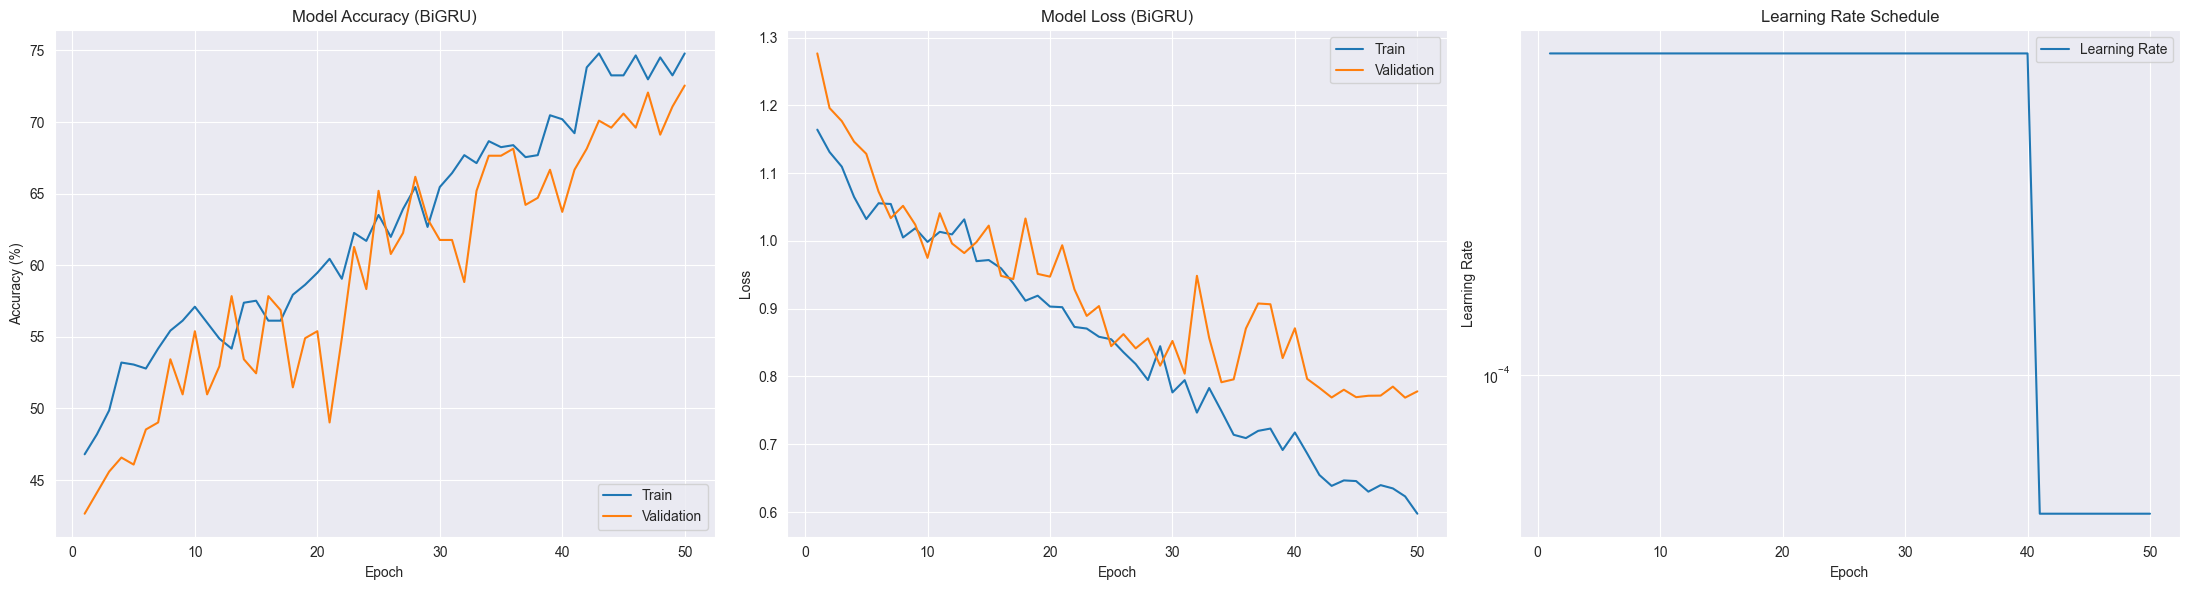


--- Evaluating BiGRU on Test Set ---


Test Accuracy (Best Validation BiGRU Model): 70.48%

--- Generating BiGRU Confusion Matrix & Classification Report ---


Generating predictions for CM: 100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


Confusion matrix plot saved as 'confusion_matrix_bigru.png'


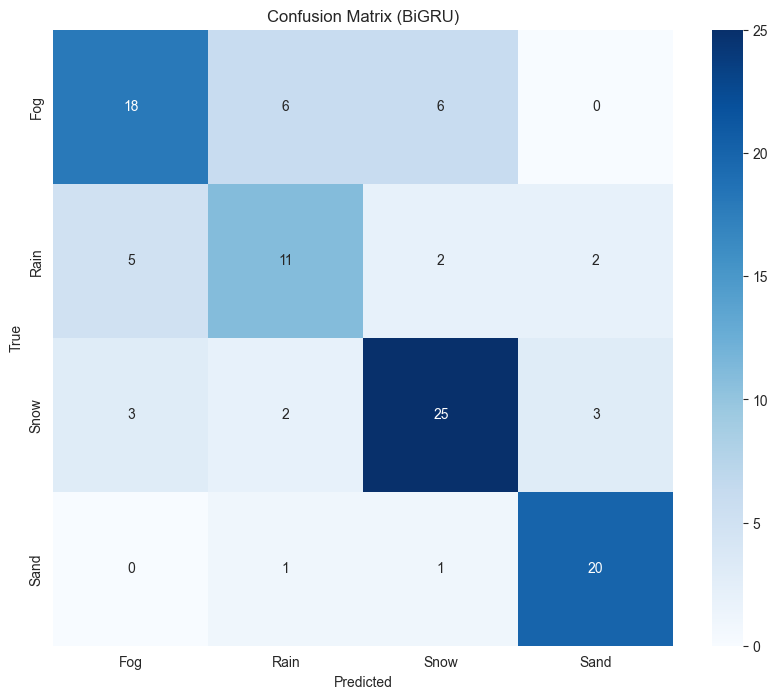


Classification Report (BiGRU):
              precision    recall  f1-score   support

         Fog       0.69      0.60      0.64        30
        Rain       0.55      0.55      0.55        20
        Snow       0.74      0.76      0.75        33
        Sand       0.80      0.91      0.85        22

    accuracy                           0.70       105
   macro avg       0.69      0.70      0.70       105
weighted avg       0.70      0.70      0.70       105


--- Visualizing BiGRU Predictions ---
Prediction examples plot saved as 'prediction_examples_bigru.png'


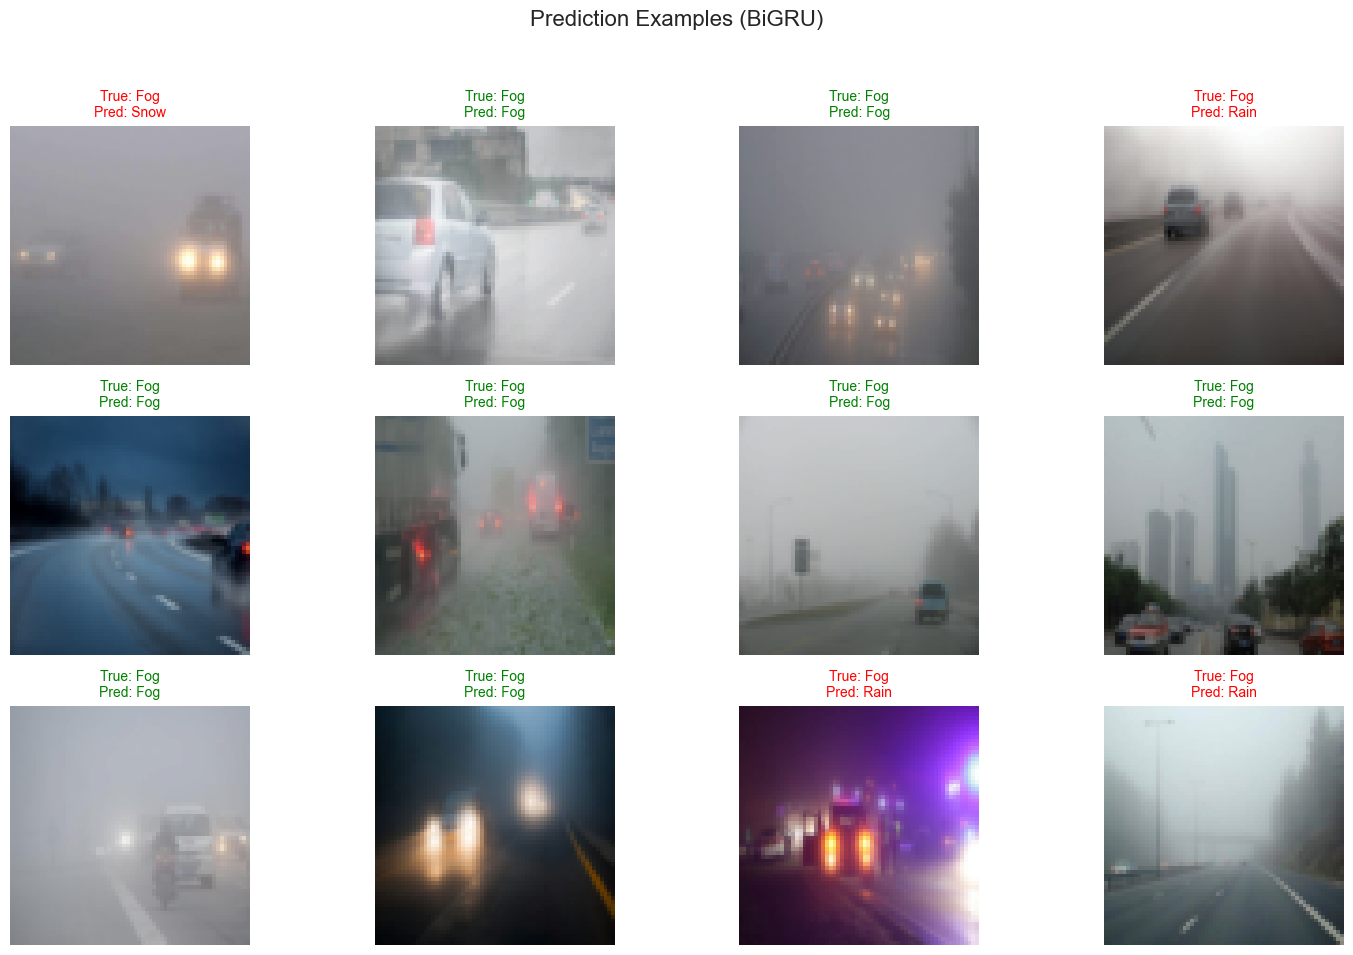


--- Example: Load BiGRU Model and Predict Single Image ---
BiGRU model loaded successfully from weather_classification_bigru_model.pth
Prediction for ../data/DAWN_processed\test\Fog\foggy-026.jpg:
  Predicted Class: Snow | Confidence: 0.4679

--- Bi-directional GRU Script Finished ---


In [12]:
# Main execution block
if __name__ == "__main__":
    # Train the BiGRU model
    model, history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, early_stopping_patience)

    # Save the trained BiGRU model
    model_save_path = 'weather_classification_bigru_model.pth' # Updated filename
    try:
        torch.save({
            'model_state_dict': model.state_dict(), 'classes': classes,
            'optimizer_state_dict': optimizer.state_dict(),
            'hyperparameters': { # Save key hyperparameters
                 'img_height': img_height, 'img_width': img_width,
                 'hidden_size': hidden_size, 'num_layers': num_layers,
                 'initial_learning_rate': initial_learning_rate, 'dropout_rate': dropout_rate,
                 'weight_decay': weight_decay }}, model_save_path)
        print(f"Best BiGRU model saved as '{model_save_path}'")
    except Exception as e: print(f"Error saving model: {e}")

    # Plotting, Evaluation, Visualization (using updated functions)
    print("\n--- Plotting BiGRU Training History ---")
    plot_training_history(history)
    print("\n--- Evaluating BiGRU on Test Set ---")
    model.eval()
    test_loss, test_acc = evaluate_model(model, test_loader)
    print(f"Test Accuracy (Best Validation BiGRU Model): {test_acc:.2f}%")
    print("\n--- Generating BiGRU Confusion Matrix & Classification Report ---")
    y_true, y_pred = plot_confusion_matrix(model, test_loader, classes)
    print("\n--- Visualizing BiGRU Predictions ---")
    visualize_predictions(model, test_loader, classes)

    # Example load and predict
    print("\n--- Example: Load BiGRU Model and Predict Single Image ---")
    if test_dataset.samples:
         example_image_path = test_dataset.samples[0][0]
         # Use the correct loading function for BiGRU
         loaded_model, loaded_classes = load_bigru_model(model_save_path)
         if loaded_model and loaded_classes:
             prediction_result = predict_image(loaded_model, example_image_path, loaded_classes)
             if prediction_result:
                 print(f"Prediction for {prediction_result['image_path']}:")
                 print(f"  Predicted Class: {prediction_result['predicted_class']} | Confidence: {prediction_result['confidence']:.4f}")
    else:
        print("Test dataset is empty or inaccessible, skipping single image prediction test.")

    print("\n--- Bi-directional GRU Script Finished ---")